<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

# Week 10 - Relative Representations with Autoencoders

Relative Representations is a technique that allows us to compare and transfer knowledge between neural networks that have learned different internal representations of the same data. By expressing data points relative to a shared set of "anchor" points, we can create a common coordinate system that enables zero-shot model stitching.

In this exercise, we'll explore relative representations using **autoencoders** instead of classifiers, demonstrating zero-shot **decoder transfer**.

At the end of this week, you should be able to:

- Build and train CNN autoencoders for image reconstruction
- Explain what relative representations are and why they enable zero-shot stitching
- Understand how cosine similarity can be used to create relative representations
- Train a decoder on relative representations from one model
- Transfer that decoder to work with a completely different model (zero-shot)
- Visualize and compare reconstruction quality

---

## The Problem: Different Networks, Same Task

When we train multiple autoencoders on the same data (e.g., MNIST), even if they achieve similar reconstruction quality, they typically learn completely different internal representations (latent spaces). This means we cannot directly combine parts from different networks - for example, using the encoder from Model A with the decoder from Model B typically fails.

**Why does this happen?** Each autoencoder converges to a different point in the loss landscape due to random initialization, different training dynamics, and the non-convexity of the optimization problem. The internal representations (embeddings) are not aligned between models.

---

## The Solution: Relative Representations

Instead of using absolute embeddings, we can express each data point **relative to a set of anchor points**. If both models use the same anchors and the same distance metric, their relative representations become aligned, even though their absolute embeddings are different.

**Key Idea:** Rather than representing a data point as a vector in embedding space, represent it as a vector of similarities/distances to a set of anchors.

For example, with 3 anchors (A, B, C) and cosine similarity:
- Absolute embedding: `[0.5, -0.3, 0.8, 0.1, ...]` (latent_dim dimensions)
- Relative representation: `[sim(x, A), sim(x, B), sim(x, C)]` (3 dimensions)

If both models use the same anchors, their relative representations will be similar even if their absolute embeddings are completely different!

**For Autoencoders:** We can train a decoder that takes relative representations as input and reconstructs images. This decoder can work with ANY encoder that produces relative representations using the same anchors!

---

## Why Cosine Similarity?

Cosine similarity measures the angle between two vectors, ignoring their magnitude:

$$\text{cosine\_similarity}(x, a) = \frac{x \cdot a}{||x|| \cdot ||a||}$$

This is equivalent to normalizing both vectors to unit length and computing their dot product. Values range from -1 (opposite) to +1 (same direction).

---

**In these exercises, you will build a complete relative representations pipeline with autoencoders from scratch, visualize how it works, and see zero-shot decoder transfer in action!**

</span>


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import random
from sklearn.decomposition import PCA

# Import our utility functions
from ex_week_10_utils import (load_mnist_data, plot_data_list, plot_embeddings_2d, 
                               plot_embeddings_comparison, plot_reconstructions,
                               load_model_if_valid, save_model)

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check if GPU is available
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 1 - Theory Questions

Before we dive into the code, let's make sure we understand the concepts.

</span>


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 1.1 - Understanding Relative Representations with Autoencoders

#### **1.1.1. Why can't we directly use the encoder from Autoencoder A with the decoder from Autoencoder B, even if both were trained on the same dataset?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** Even though both autoencoders are trained on the same data and achieve similar reconstruction quality, they learn different internal representations (latent spaces) due to:
1. **Different random initializations** - Each autoencoder starts from a different point in parameter space
2. **Non-convex optimization** - There are many different local minima that achieve good reconstruction
3. **Different training dynamics** - Stochastic gradient descent follows different paths for each model

This means the embeddings from Autoencoder A live in a completely different coordinate system than what Autoencoder B's decoder expects. The decoder has learned to reconstruct images from Autoencoder A's specific embedding space, which doesn't transfer to Autoencoder B's space.

</span>

#### **1.1.2. If we have $m$ anchor points, what is the dimensionality of the relative representation for each data point?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** The dimensionality is exactly $m$. Each data point is represented by its similarity/distance to each of the $m$ anchors, giving us an $m$-dimensional vector.

This is independent of the original embedding dimensionality! If our embeddings are 64-dimensional and we use 64 anchors, the relative representation is 64-dimensional (though these could be different numbers!).

</span>

#### **1.1.3. Suppose we have a data point with embedding $x = [1, 0, 0]$ and an anchor $a = [0, 1, 0]$. What is their cosine similarity?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** 
$$\text{cosine\_similarity}(x, a) = \frac{x \cdot a}{||x|| \cdot ||a||} = \frac{1 \cdot 0 + 0 \cdot 1 + 0 \cdot 0}{\sqrt{1^2 + 0^2 + 0^2} \cdot \sqrt{0^2 + 1^2 + 0^2}} = \frac{0}{1 \cdot 1} = 0$$

The vectors are orthogonal (perpendicular), so their cosine similarity is 0.

</span>


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 2 - Data Loading and Preparation

Let's load the MNIST dataset. We'll split it into train, validation, and test sets.

</span>


In [25]:
# Load MNIST data using our utility function
train_loader, val_loader, test_loader = load_mnist_data(batch_size=128, validation_split=0.1)

print("Data loaded successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Data loaded successfully!
Train batches: 422
Validation batches: 47
Test batches: 79


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 3 - Building a CNN Autoencoder

Autoencoders are networks that compress data into a latent space and then does reconstruction, classification, segmentation, or something else depending on the task at hand. The important idea is that **it compresses the data into a latent space which can be used to achieve the task**. We'll build a **CNN Autoencoder** that learns to compress and reconstruct MNIST images.

We'll create a complete autoencoder with two components:

1. **Encoder**: Compresses 28×28 images → low-dimensional latent space (e.g., 64D)
2. **Decoder**: Reconstructs 28×28 images from the latent space

**Encoder Architecture:**
- Conv2D (16 kernels) + ReLU + BatchNorm + MaxPool 28x28 → 14x14
- Conv2D (32 kernels) + ReLU + BatchNorm + MaxPool 14x14 → 7x7
- Flatten + Linear layers → latent_dim 64

**Decoder Architecture:**
- Linear layers → 32×7×7 features
- Unflatten to spatial dimensions
- ConvTranspose2D (32→16 channels) + ReLU + BatchNorm → 14×14
- ConvTranspose2D (16→1 channel) + Sigmoid → 28×28

**Note on Transposed Convolution (ConvTranspose2D):**

*Not part of the curriculum, but definitely good to know!*

You know regular convolution reduces spatial dimensions (e.g., 28×28 → 14×14). **Transposed convolution does the opposite** - it increases spatial dimensions for reconstruction.
- Regular Conv: many input pixels → one output pixel (compression)
- Transposed Conv: one input pixel → many output pixels (expansion)
- With `stride=2`, each ConvTranspose2D roughly doubles the spatial size
- In our decoder: 7×7 → 14×14 → 28×28 (back to original image size)

---

**Key Point:** Later, we'll train a **separate decoder** that takes **relative representations** as input instead of absolute embeddings, enabling zero-shot transfer!

</span>


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 3.1 - 💻 Building the CNN Autoencoder

Now it's time to build your autoencoder! Complete the architecture below by implementing the encoder and decoder methods.

**Your tasks:**
1. Fill in the `...` in the encoder Sequential (create the Conv2d, ReLU, BatchNorm, MaxPool layers as described in Part 3)
2. Complete the decoder's input dimension (hint: it should match the latent_dim)
3. Implement the `encode()`, `decode()`, and `forward()` methods

</span>


In [26]:
class CNNAutoencoder(nn.Module):
    """
    CNN Autoencoder for MNIST images.
    Compresses 28×28 images into a low-dimensional latent space and reconstructs them.
    """
    def __init__(self, latent_dim=32):
        super(CNNAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder: CNN layers
        self.encoder = nn.Sequential(
            # Input: (batch, 1, 28, 28) #This tells us that there is only 1 color channel in the mnist images
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2, 2),  # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),  # 14x14 -> 7x7
            nn.Flatten(),
            # Add intermediate layer
            nn.Linear(32 * 7 * 7, 128), # Think about why it is 32 * 7 * 7 (hint: How many kernels are there in the last conv layer?)
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )
        
        # Decoder: Transpose CNN layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 32 * 7 * 7), # Hint: We are basically constructing the inverse of the encoder
            nn.ReLU(),
            nn.BatchNorm1d(32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def encode(self, x):
        """Extract embeddings from input images."""
        return self.encoder(x)
    
    def decode(self, z):
        """Reconstruct images from embeddings."""
        return self.decoder(z)
    
    def forward(self, x):
        """Forward pass: encode then decode."""
        # TODO: First encode the input, then decode the latent representation
        latent_embedding = self.encode(x)
        x_recon = self.decode(latent_embedding)
        return x_recon


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 3.2 - 💻 Training Functions

Implement the training and evaluation functions for the autoencoder.




In [27]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train autoencoder for one epoch"""
    model.train()
    total_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        
        # TODO: Forward pass - get reconstruction from model
        reconstructions = model(images)
        
        # TODO: Compute loss between reconstructions and original images
        loss = criterion(reconstructions, images)
        
        # TODO: Backward pass - zero gradients, backward, and update weights. You have worked with this before, look through old exercises and assignments if you are in doubt
        # You will write these 3 lines a billion times in your lives as AI engineers, so better get used to them now ;)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

def evaluate(model, loader, criterion, device):
    """Evaluate autoencoder on a dataset"""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # TODO: Forward pass - get reconstruction from model
            reconstructions = model(images)
            
            # TODO: Compute loss between reconstructions and original images
            loss = criterion(reconstructions, images)
            
            # Track metrics
            total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    """Complete training loop for autoencoder"""
    model = model.to(device)
    criterion = nn.MSELoss()  # Reconstruction loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate(model, val_loader, criterion, device)
        
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss: {val_loss:.6f}")
    
    return model

<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Training Two Autoencoders

Now we'll train two separate autoencoders with different random seeds. They will learn different latent representations even though they're trained on the same data!

</span>




<span style="background-color: #003D5C; padding:8px; display:block; border-left:4px solid #4682b4">

**Model Caching:** The code below automatically saves trained models and loads them on subsequent runs. If you change the model architecture, it will detect the change and retrain automatically.

</span>


In [28]:
# Hyperparameters
latent_dim = 64  # Latent space dimension
num_epochs = 5   # Number of training epochs
learning_rate = 0.001

# Model save paths (saved in models/ directory)
model1_path = 'models/model1_ae.pth'
model2_path = 'models/model2_ae.pth'

# Train or load Autoencoder 1 with seed 42
print("="*60)
print("Autoencoder 1 (seed=42)")
print("="*60)
set_seed(42)
model1, loaded = load_model_if_valid(model1_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    print("Training Autoencoder 1...")
    model1 = CNNAutoencoder(latent_dim=latent_dim)
    model1 = train_model(model1, train_loader, val_loader, num_epochs, learning_rate, device)
    save_model(model1, model1_path, CNNAutoencoder, latent_dim=latent_dim)

# Train or load Autoencoder 2 with seed 123
print("\n" + "="*60)
print("Autoencoder 2 (seed=123)")
print("="*60)
set_seed(123)
model2, loaded = load_model_if_valid(model2_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    print("Training Autoencoder 2...")
    model2 = CNNAutoencoder(latent_dim=latent_dim)
    model2 = train_model(model2, train_loader, val_loader, num_epochs, learning_rate, device)
    save_model(model2, model2_path, CNNAutoencoder, latent_dim=latent_dim)

print("\n" + "="*60)
print("Both autoencoders ready!")
print("="*60)


Autoencoder 1 (seed=42)
Loaded pre-trained model from models/model1_ae.pth

Autoencoder 2 (seed=123)
Loaded pre-trained model from models/model2_ae.pth

Both autoencoders ready!


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 3.4 - 💻 Testing the Autoencoders

Put both models in evaluation mode and get reconstructions from each.

```


Reconstruction Examples from Both Autoencoders
Saved visualization to 'autoencoder_reconstructions.png'


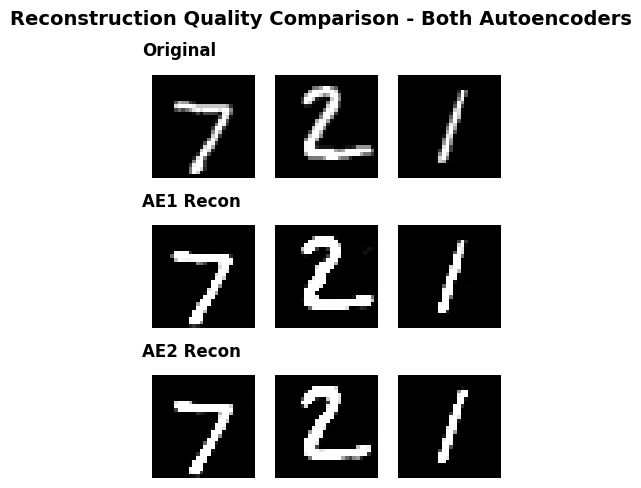

In [29]:
# Show reconstruction examples from both trained autoencoders
print("="*60)
print("Reconstruction Examples from Both Autoencoders")
print("="*60)

# Get a small batch of test images for visualization
test_images_batch, test_labels_batch = next(iter(test_loader))
num_examples = 3
test_images_vis = test_images_batch[:num_examples].to(device)

# Unnormalize images for proper visualization (reverse the normalization)
test_images_unnorm = test_images_vis * 0.3081 + 0.1307
test_images_unnorm = torch.clamp(test_images_unnorm, 0, 1)

# Get reconstructions from both models

#TODO: Put both models into eval mode. This has been done before in previous exercises and assignments
model1.eval()
model2.eval()
with torch.no_grad():
    #TODO: Get reconstructions from each model
    recon1 = model1(test_images_vis)
    recon2 = model2(test_images_vis)

# Plot reconstructions using the utility function
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon1.cpu(), recon2.cpu()],
    row_labels=['Original', 'AE1 Recon', 'AE2 Recon'],
    num_samples=num_examples,
    suptitle='Reconstruction Quality Comparison - Both Autoencoders',
    save_path='autoencoder_reconstructions.png'
)
plt.show()


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 4 - Extracting and Visualizing Embeddings

Now that we have two trained autoencoders, let's extract their latent embeddings and see how different they are.

We'll extract embeddings for the test set and visualize them using PCA (Principal Component Analysis).

</span>


In [30]:
def extract_embeddings(model, loader, device):
    """Extract embeddings and labels from a dataset"""
    model.eval()
    embeddings_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # Get embeddings (encoder only, no classifier)
            emb = model.encode(images)
            
            embeddings_list.append(emb.cpu())
            labels_list.append(labels)
    
    # Concatenate all batches
    embeddings = torch.cat(embeddings_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return embeddings, labels

# Extract embeddings from both models on the test set
print("Extracting embeddings from Model 1...")
embeddings1, labels1 = extract_embeddings(model1, test_loader, device)

print("Extracting embeddings from Model 2...")
embeddings2, labels2 = extract_embeddings(model2, test_loader, device)

print(f"\nModel 1 embeddings shape: {embeddings1.shape}")
print(f"Model 2 embeddings shape: {embeddings2.shape}")
print(f"Labels shape: {labels1.shape}")

# Verify labels are the same (they should be, since we use the same test set)
assert np.array_equal(labels1, labels2), "Labels should be identical!"
labels = labels1  # Use either one


Extracting embeddings from Model 1...
Extracting embeddings from Model 2...

Model 1 embeddings shape: (10000, 64)
Model 2 embeddings shape: (10000, 64)
Labels shape: (10000,)


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Applying PCA for Visualization

Our embeddings are 64-dimensional, which we cannot directly visualize. We'll use **PCA (Principal Component Analysis)** to project them to 2D.

**What is PCA?**

PCA finds the directions of maximum variance in your data:
- **PC1 (1st principal component)**: Direction of highest variance
- **PC2 (2nd principal component)**: Direction of 2nd highest variance (orthogonal to PC1)

By projecting onto these two directions, we preserve as much information as possible in 2D.

We'll use scikit-learn's PCA implementation to fit on Model 1's embeddings and Model 2's embeddings separately (since they're in different spaces), then transform both to 2D.

</span>




In [31]:
# Apply PCA to project 64D embeddings to 2D for visualization

from sklearn.decomposition import PCA

# Model 1: Fit PCA and transform
pca1 = PCA(n_components=2)
embeddings1_2d = pca1.fit_transform(embeddings1)

# Model 2: Fit separate PCA and transform (different embedding space!)
pca2 = PCA(n_components=2)
embeddings2_2d = pca2.fit_transform(embeddings2)


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Plotting the Embeddings

Now let's plot the embeddings from both models side by side to see how they compare.

</span>




/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


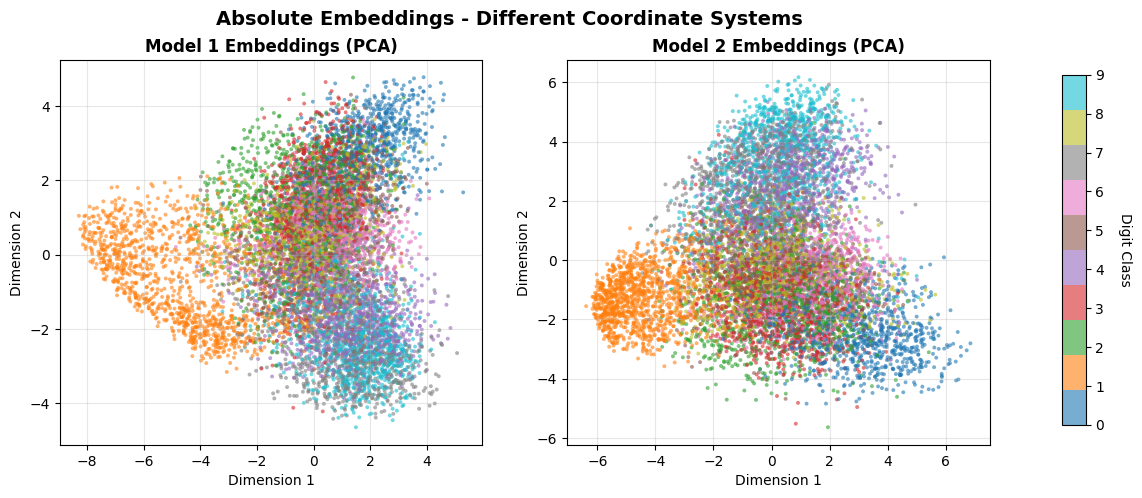

In [32]:


# Plot the 2D projections side by side
fig, axes = plot_embeddings_comparison(
    embeddings1_2d, embeddings2_2d, labels,
    title1='Model 1 Embeddings (PCA)', 
    title2='Model 2 Embeddings (PCA)',
    suptitle='Absolute Embeddings - Different Coordinate Systems'
)
plt.show()


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 4.3 - Observations

#### **4.3.1. What do you observe about the structure of the embeddings from Autoencoder 1 vs Autoencoder 2?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** Both autoencoders tend to cluster similar digits together (same classes form clusters), which shows they've both learned meaningful representations.

However, the **coordinate systems are completely different**:
- Clusters are in different positions
- Rotated relative to each other
- Scaled differently
- Different overall geometry

This is why we can't directly use Autoencoder 1's encoder with Autoencoder 2's decoder!

</span>

#### **4.3.2. Why do both autoencoders cluster similar digits together despite different initializations?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** Both autoencoders optimize the same objective (reconstruction error). The gradient descent process naturally encourages:
1. Grouping similar inputs (same digit) together in embedding space
2. Preserving important features needed for reconstruction

This clustering emerges because similar images (e.g., all 7's) share similar features, so the encoder naturally maps them to nearby points in latent space. The decoder then uses this clustered structure to reconstruct images effectively.

Even though the autoencoders converge to different local minima with different coordinate systems, they both learn this clustering property because it helps minimize reconstruction error.

</span>


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 5 - Zero-shot Stitching Without Relative Representations

If we try to use the encoder from Autoencoder 1 with the decoder from Autoencoder 2, reconstruction will fail because their latent spaces are completely different. The decoder expects embeddings from its own encoder, not from a different one.

**This is where relative representations come in (later)!** By converting embeddings to relative representations using shared anchors, we can create a common coordinate system that enables zero-shot decoder transfer. But first we look at the horrible results that we get without them.

</span>


Saved visualization to 'failed_stitching_comparison.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


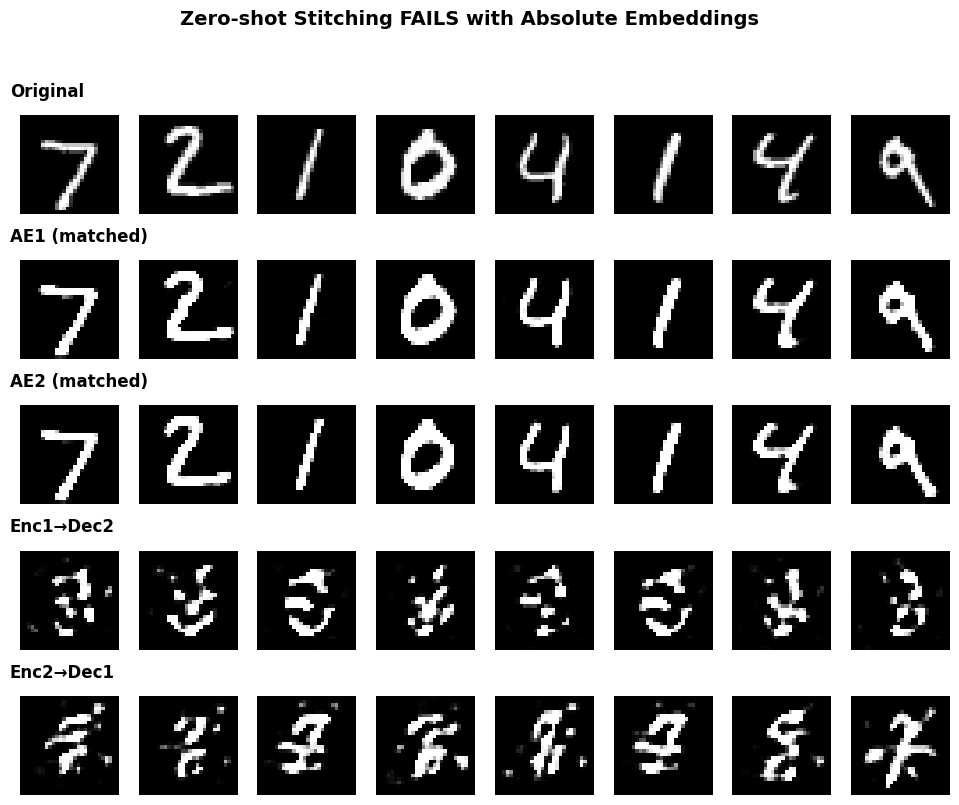

In [33]:
model1.eval()
model2.eval()

# Take 8 test images for visualization (unnormalized for plotting)
vis_images, _ = next(iter(test_loader))
vis_images = vis_images[:8].to(device)
vis_images_unnorm = vis_images * 0.3081 + 0.1307

with torch.no_grad():
    vis_recon1 = model1(vis_images)
    vis_recon2 = model2(vis_images)
    
    # Mismatched reconstructions
    vis_emb1 = model1.encode(vis_images)
    vis_recon1_to_2 = model2.decode(vis_emb1)
    
    vis_emb2 = model2.encode(vis_images)
    vis_recon2_to_1 = model1.decode(vis_emb2)

# Use utility function to plot
plot_reconstructions(
    images_list=[vis_images_unnorm, vis_recon1, vis_recon2, vis_recon1_to_2, vis_recon2_to_1],
    row_labels=['Original', 'AE1 (matched)', 'AE2 (matched)', 'Enc1→Dec2', 'Enc2→Dec1'],
    num_samples=8,
    suptitle='Zero-shot Stitching FAILS with Absolute Embeddings',
    save_path='failed_stitching_comparison.png'
)
plt.show()

<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">
Notice how the mismatched reconstructions (rows 4-5) are completely garbled!

The decoders expect embeddings from their own encoder, not from a different one.
</span>

<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 6 - Computing Relative Representations

Now we will use relative representations to create a shared coordinate system.

</span>


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 6.1 - 💻 Selecting Anchor Points

Extract anchor embeddings from both autoencoders using the randomly selected `anchor_indices`.




In [34]:
# Number of anchors - can be different from latent dimension!
num_anchors = 16 # TODO: Play around with this number if you like!

# Randomly select anchor indices
np.random.seed(42)  # For reproducibility
anchor_indices = np.random.choice(len(embeddings1), size=num_anchors, replace=False)

# Extract anchor embeddings from both autoencoders
# TODO: IMPORTANT: Use the same indices for both models such that the anchors are PARALLEL!
anchors1 = embeddings1[anchor_indices]
anchors2 = embeddings2[anchor_indices]

<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 6.2 - 💻 Computing Cosine Similarity Relative Representations

Complete the `compute_relative_representations` function to compute cosine similarities between embeddings and anchors.




In [35]:
def compute_relative_representations(embeddings, anchors):
    """
    Compute relative representations using cosine similarity.
    
    Args:
        embeddings: numpy array of shape (n_samples, embedding_dim)
        anchors: numpy array of shape (n_anchors, embedding_dim)
    
    Returns:
        relrep: numpy array of shape (n_samples, n_anchors)
    """
    n_samples = embeddings.shape[0]
    n_anchors = anchors.shape[0]
    
    # Initialize relative representation matrix
    relrep = np.zeros((n_samples, n_anchors))
    
    # Compute cosine similarity for each (data point, anchor) pair
    for i in range(n_samples):
        x = embeddings[i]  # Current data point
        # TODO: Compute the norm (magnitude) of x using np.linalg.norm
        norm_x = np.linalg.norm(x)  # ||x||
        
        for j in range(n_anchors):
            a = anchors[j]  # Current anchor
            # TODO: Compute the norm (magnitude) of a
            norm_a = np.linalg.norm(a)  # ||a||
            
            # TODO: Compute cosine similarity (defined earlier)
            # Use np.dot for the dot product, add 1e-8 to denominator to avoid division by zero
            dot_product = np.dot(x, a)
            cosine_sim = dot_product / (norm_x * norm_a + 1e-8)
            
            relrep[i, j] = cosine_sim
    
    return relrep

# Compute relative representations for both models
relrep1 = compute_relative_representations(embeddings1, anchors1)
relrep2 = compute_relative_representations(embeddings2, anchors2)

print(f"Original embedding dimension: {latent_dim}")
print(f"Relative representation dimension: {num_anchors}")
print("Relative representations shape:", relrep1.shape)


Original embedding dimension: 64
Relative representation dimension: 16
Relative representations shape: (10000, 16)


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Visualizing Relative Representations

Now let's visualize the relative representations. Since they are high-dimensional, we will use PCA again.

For relative representations, it is important to use the SAME PCA fitted on the first model's data and apply it to both models. This ensures we are comparing them in the same coordinate system.

</span>




Plotting relative representations...


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:309: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0, 1.0, 0.95, 1))


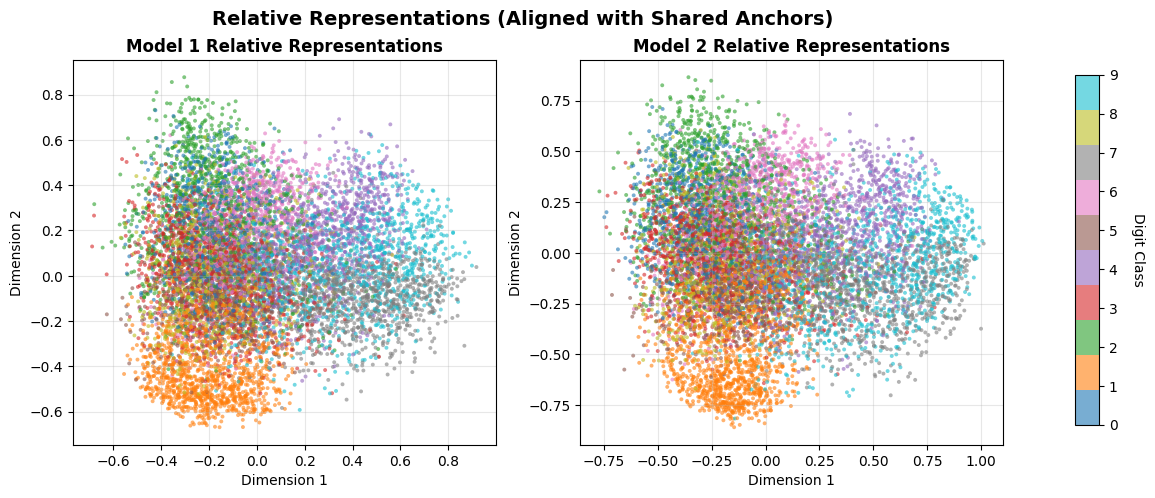

In [36]:
# Plot relative representations
print("Plotting relative representations...")

# # Apply PCA to reduce dimensions for visualization (shared PCA for both)
# pca_relrep = PCA(n_components=2)
# relrep1_2d = pca_relrep.fit_transform(relrep1)
# relrep2_2d = pca_relrep.transform(relrep2)  # Use same PCA transformation

concat_relrep = np.concatenate([relrep1, relrep2], axis=0)
pca_relrep = PCA(n_components=2).fit_transform(concat_relrep)
relrep1_2d = pca_relrep[:len(relrep1)]
relrep2_2d = pca_relrep[len(relrep1):]


# Plot using our utility function
fig, axes = plot_embeddings_comparison(
    relrep1_2d, relrep2_2d, labels,
    title1='Model 1 Relative Representations',
    title2='Model 2 Relative Representations',
    suptitle='Relative Representations (Aligned with Shared Anchors)'
)
plt.show()


In [37]:
7718+846+423+405+1352+2976+1975+554+18199+1298+9478+3097+1109+1164+2798

53392

<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

Holy moly, would you look at that?! Despite a few small discrepancies that could be the result of the PCA, the spaces are incredibly aligned.

Btw: The reason that many of the classes are overlapping is because we are looking at a 2D slice of a 64 dim space. In the high-dim space itself, they are properly seperated.

</span>


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 7 - Training a Decoder on Relative Representations

Now comes the exciting part! We will train a **RelativeDecoder** that takes relative representations as input and reconstructs images.

We'll train it on Autoencoder 1's relative representations, then test it with Autoencoder 2's relative representations (zero-shot transfer)!

Since the relative representations are aligned, the decoder trained on one model's relreps should work with the other model's relreps.

</span>


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 7.1 - 💻 Building the Relative Decoder

Complete the RelativeDecoder architecture by copying the decoder layers from the CNNAutoencoder.




In [38]:
# Similar structure to the autoencoder's decoder, but takes relrep as input

class RelativeDecoder(nn.Module):
    """
    Decoder that takes relative representations as input and reconstructs images.
    """
    def __init__(self, input_dim):
        super(RelativeDecoder, self).__init__()
        
        # Decode directly from relative representations to images
        self.decoder = nn.Sequential(
            # Map from relrep dimension to intermediate size
            # TODO: This is just a new decoder. You can just straight up copy the decoder architecture in here and change the input var
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 32 * 7 * 7), # Hint: We are basically constructing the inverse of the encoder
            nn.ReLU(),
            nn.BatchNorm1d(32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] range
        )
    
    def forward(self, relrep):
        """Forward pass: decode from relrep to image."""
        return self.decoder(relrep)


# Get original images for training the decoder
# We need to pair relreps with their corresponding images
print("Preparing datasets for RelativeDecoder training...")

# Convert numpy arrays to tensors
relrep1_tensor = torch.FloatTensor(relrep1)
relrep2_tensor = torch.FloatTensor(relrep2)

# Get images from test set (need to unnormalize and reshape properly)
images_list = []
for images, labels_batch in test_loader:
    images_list.append(images)
images_all = torch.cat(images_list, dim=0)

# Unnormalize images (reverse the normalization: x * std + mean)
images_all = images_all * 0.3081 + 0.1307
images_all = torch.clamp(images_all, 0, 1)  # Ensure in [0, 1] range

# Create datasets: (relrep, image) pairs
relrep1_dataset = TensorDataset(relrep1_tensor, images_all)
relrep2_dataset = TensorDataset(relrep2_tensor, images_all)

relrep1_loader = DataLoader(relrep1_dataset, batch_size=128, shuffle=True)
relrep2_loader = DataLoader(relrep2_dataset, batch_size=128, shuffle=False)

Preparing datasets for RelativeDecoder training...


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 7.2 - 💻 Training the Relative Decoder

Initialize the RelativeDecoder and implement the backward pass in the training loop.




In [39]:
# Train the RelativeDecoder on Autoencoder 1's relative representations
print("="*60)
print("RelativeDecoder on Autoencoder 1's relreps")
print("="*60)

# Initialize the RelativeDecoder
rel_decoder = RelativeDecoder(input_dim=num_anchors) # TODO: What is the dim of the relative space equal to?
rel_decoder = rel_decoder.to(device)

num_epochs_rel = 25
optimizer = torch.optim.Adam(rel_decoder.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()  # Reconstruction loss

for epoch in range(num_epochs_rel):
    rel_decoder.train()
    train_loss = 0.0
    
    for relreps, images_batch in relrep1_loader:
        relreps = relreps.to(device)
        images_batch = images_batch.to(device)
        
        # Forward pass: decode relreps to images
        reconstructions = rel_decoder(relreps)
        loss = criterion(reconstructions, images_batch)
        
        # TODO: Backward pass - zero gradients, backward, and update weights.
        # Here are the 3 lines again!
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
    
    avg_loss = train_loss / len(relrep1_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_rel - 1:
        print(f"Epoch {epoch+1}/{num_epochs_rel}: Loss = {avg_loss:.6f}")

print("\n✓ RelativeDecoder training complete!")


RelativeDecoder on Autoencoder 1's relreps
Epoch 1/25: Loss = 0.161622
Epoch 5/25: Loss = 0.028504
Epoch 10/25: Loss = 0.022438
Epoch 15/25: Loss = 0.020647
Epoch 20/25: Loss = 0.019873
Epoch 25/25: Loss = 0.019084

✓ RelativeDecoder training complete!


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 7.3 - 💻 Zero-shot Reconstruction with Autoencoder 2

Pass what needs to be passed to the RelativeDecoder to get zero-shot reconstructions.




Saved visualization to 'reconstruction_comparison.png'


/Users/aslandalhoffbehbahani/Bachelor/VSBachelor/src/lora/ex_week_10_utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97 if suptitle else 1])


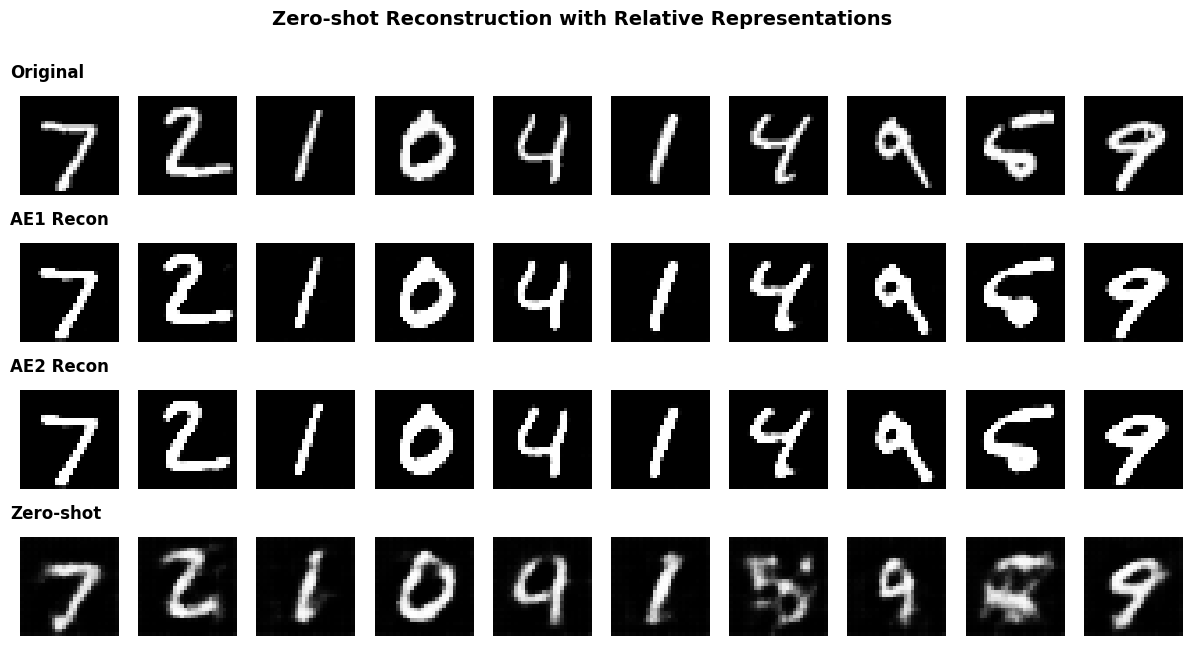

In [40]:
## Getting the reconstructions and plotting ##

# Visualize reconstructions
num_samples = 10

# Get a batch of test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:num_samples].to(device)
test_labels = test_labels[:num_samples]

# Unnormalize for visualization
test_images_unnorm = test_images * 0.3081 + 0.1307

# Get direct reconstructions from both autoencoders
# Don't mind the .cpu() and FLoatTensor stuff. It's just to make sure that it works with numpy and plt
with torch.no_grad():
    recon_model1 = model1(test_images).cpu()
    recon_model2 = model2(test_images).cpu()
    
    # Get embeddings from model2
    emb_model2 = model2.encode(test_images).cpu().numpy()
    
    # Compute relreps for these embeddings using our function
    relrep_embeddings = compute_relative_representations(emb_model2, anchors2)
    relrep_embeddings = torch.FloatTensor(relrep_embeddings).to(device)
    
    # Zero-shot reconstruction
    recon_zeroshot = rel_decoder(relrep_embeddings).cpu() #TODO: What are we putting into the relative decoder??

# Use utility function to plot
plot_reconstructions(
    images_list=[test_images_unnorm.cpu(), recon_model1, recon_model2, recon_zeroshot],
    row_labels=['Original', 'AE1 Recon', 'AE2 Recon', 'Zero-shot'],
    num_samples=num_samples,
    suptitle='Zero-shot Reconstruction with Relative Representations',
    save_path='reconstruction_comparison.png'
)
plt.show()

<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

(Note: This is not perfect - albeit MUCH better than non relrep and quite mindblowing if you think about it - and there are some checkerboard reconstruction artifacts. This can be fixed with a more complex model, which we won't go into today. Specifically, checkerboard artifacts can be remove by e.g. using upsampling followed by convolution layers instead of transposed convolution)

</span>

<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 7.4 - Understanding the Results

#### **7.4.1. Why does zero-shot decoder transfer work with relative representations?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** With relative representations, both autoencoders are using the **same coordinate system** defined by the shared anchors. 

When we compute relative representations using the same anchors and same similarity metric (cosine similarity), we create a common reference frame. A data point that is similar to anchor A in Autoencoder 1's embedding space will also be similar to anchor A in Autoencoder 2's embedding space, even though the absolute embeddings are completely different.

This alignment allows the RelativeDecoder (trained on Autoencoder 1's relreps) to successfully reconstruct images from Autoencoder 2's relreps without any additional training.

</span>

#### **7.4.2. What would happen if we used different anchors for each autoencoder?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** If we used different anchors for each autoencoder, the alignment would be lost! The relative representations would be as incompatible as the absolute embeddings.

For example, if Autoencoder 1 uses anchor points from digit "0" images and Autoencoder 2 uses anchor points from digit "9" images, the similarity patterns would be completely different. The whole point of relative representations is that both autoencoders measure similarity to the **same reference points**.

</span>

#### **7.4.3. Why can we use a different number of anchors than the latent dimension?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** The number of anchors is **independent of the latent dimension**! This is a key insight:

1. **Flexible dimensionality**: Relative representations create a completely new coordinate system. If we use 64 anchors with 64D embeddings, we get 64D relative representations (though we could use any number of anchors!).

2. **Information tradeoff**: 
   - More anchors = richer relative representation = potentially better reconstruction
   - Fewer anchors = more compact representation = faster computation

3. **No strict requirement**: The anchors don't need to "span" the embedding space. They just need to provide diverse reference points that capture the structure of the data.

4. **Practical consideration**: We often use more anchors than the latent dim for better performance, or fewer anchors for efficiency.

The key is that the RelativeDecoder learns to reconstruct from whatever number of anchors we choose!

</span>


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 8 - (No coding) Exploring Relative Representations with 2 Anchors

Now let's explore what happens when we compute relative representations with only 2 anchors. This will help us understand the geometric properties of cosine similarity and think critically about our design choices.

To make this visualization clearer, we'll train a new autoencoder with a 2-dimensional latent space. Then we'll select 2 anchors and compute relative representations, creating a 2D representation that we can visualize directly without needing PCA.

</span>


In [41]:
# Train a new autoencoder with 2D latent space
latent_dim = 2
model_2d_path = 'models/model_2d_ae.pth'

set_seed(42)
model_2d, loaded = load_model_if_valid(model_2d_path, CNNAutoencoder, device, latent_dim=latent_dim)
if not loaded:
    model_2d = CNNAutoencoder(latent_dim=latent_dim)
    model_2d = train_model(model_2d, train_loader, val_loader, 5, learning_rate, device)
    save_model(model_2d, model_2d_path, CNNAutoencoder, latent_dim=latent_dim)

# Extract 2D embeddings
embeddings_2d, labels_2d = extract_embeddings(model_2d, test_loader, device)

# Select 2 anchors from the 2D embedding space
num_anchors_2 = 2
print(f"\nSelecting {num_anchors_2} random anchors...")
np.random.seed(100)
anchor_indices_2 = np.random.choice(len(embeddings_2d), size=num_anchors_2, replace=False)
anchors_2d = embeddings_2d[anchor_indices_2]

# Compute relative representations with 2 anchors
relrep_2d_2anchors = compute_relative_representations(embeddings_2d, anchors_2d)


Loaded pre-trained model from models/model_2d_ae.pth

Selecting 2 random anchors...


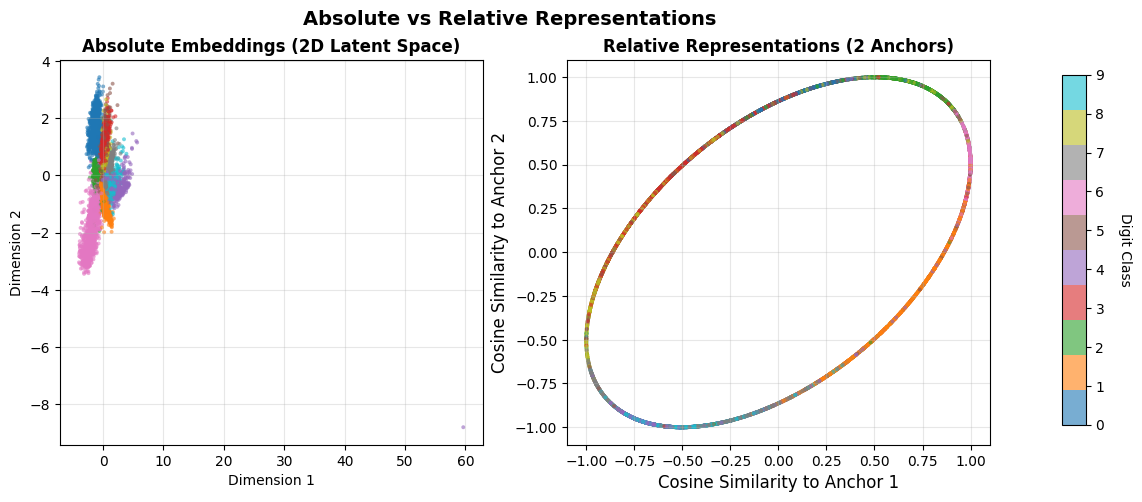

In [42]:
# Plot absolute embeddings vs 2-anchor relative representations side by side

fig, axes = plot_embeddings_comparison(
    embeddings_2d, relrep_2d_2anchors, labels_2d,
    title1='Absolute Embeddings (2D Latent Space)', 
    title2='Relative Representations (2 Anchors)',
    suptitle='Absolute vs Relative Representations'
)

# Update labels for the right plot
axes[1].set_xlabel('Cosine Similarity to Anchor 1', fontsize=12)
axes[1].set_ylabel('Cosine Similarity to Anchor 2', fontsize=12)

plt.show()


<span style="background-color: #545454; padding:8px; display:block; border-left:4px solid #4682b4">

### Exercise 8.1 - Thinking Critically About Cosine Similarity

#### **8.1.1. Why do the relative representations form an elliptical pattern when using only 2 anchors?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Intuitive Answer:** Imagine two orthogonal anchors. If the cosine similarity between a point and anchor_1 is = 0 then the point is either in the same or opposite direction of the anchor_2 vector - aka cosine similarity = 1 or = -1. So given the cosine similarity to one anchor, there are only TWO possibilities for the cosine similarity to the other anchor. This creates a circle (boom!). If the anchors are not orthogonal, it becomes an elipse.

In general: Cosine similarity maps points to the edge of a hypersphere. In 2d with 2 anchors, that becomes an elipse.

**Mathematical Proof Answer That You Probably Won't Waste Your Time Reading:** The ellipse is a perfect mathematical consequence of cosine similarity. Here's the proof:

Let the two anchors be $\hat{a}_1$ and $\hat{a}_2$ (normalized), and let any data point $x$ be normalized to $\hat{x}$. In 2D, we can write these as unit vectors at angles: $\hat{x} = (\cos\phi, \sin\phi)$, $\hat{a}_1 = (\cos\alpha_1, \sin\alpha_1)$, $\hat{a}_2 = (\cos\alpha_2, \sin\alpha_2)$.

The relative representation is:
$$r_1 = \hat{x} \cdot \hat{a}_1 = \cos(\phi - \alpha_1) = \cos\theta_1$$
$$r_2 = \hat{x} \cdot \hat{a}_2 = \cos(\phi - \alpha_2) = \cos\theta_2$$

Note that $\theta_2 - \theta_1 = \alpha_1 - \alpha_2 = \Delta$ is constant (the angle between anchors).

Using the cosine difference formula:
$$r_2 = \cos(\theta_1 - \Delta) = \cos\theta_1 \cos\Delta + \sin\theta_1 \sin\Delta$$

Substituting $\cos\theta_1 = r_1$ and $\sin\theta_1 = \pm\sqrt{1-r_1^2}$, then squaring:
$$(r_2 - r_1\cos\Delta)^2 = (1-r_1^2)\sin^2\Delta$$

Expanding:
$$r_1^2 + r_2^2 - 2r_1 r_2 \cos\Delta = \sin^2\Delta$$

This is the equation of a **perfect ellipse**. When $\Delta = 90°$ (orthogonal anchors), it simplifies to:
$$r_1^2 + r_2^2 = 1$$

which is a perfect circle!

</span>

#### **8.1.2. Given that cosine similarity normalizes vectors, is this the optimal choice for computing relative representations? What information might we be losing?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** Cosine similarity is not necessarily optimal. By normalizing vectors, we are deliberately discarding magnitude information, which could be important. The norm/length of embeddings might encode meaningful information - often confidence, certainty, or feature strength.

While cosine similarity is popular and works well in high dim spaces, it's not the only option, and the choice depends on what properties of the data we want to preserve.

</span>

#### **8.1.3. What alternative anchor selection methods and distance metrics could we use instead of random anchors and cosine similarity?**

<span style="background-color: #00590D; padding:8px; display:block; border-left:4px solid #4682b4">

**Answer:** There are several alternatives worth considering:

**Anchor Selection:**
- **K-means clustering:** Instead of random selection, use k-means to find cluster centers. This distributes anchors more evenly across the data space, ensuring better coverage of different regions
- **Furthest point sampling (FPS):** Iteratively select anchors that are maximally distant from already-selected anchors
- **Class-based selection:** Choose representative samples from each class

**Distance Metrics:**
- **Mahalanobis distance:** This metric is invariant to translation, rotation, and scale (like cosine similarity), but **does not remove vector magnitude**. It accounts for correlations in the data by using the covariance matrix:
  $$d_{Mahalanobis}(x, a) = \sqrt{(x - a)^T \Sigma^{-1} (x - a)}$$
  where $\Sigma$ is the covariance matrix of the data
- **Euclidean distance:** Simple L2 distance, preserves magnitude
- **Learned similarity:** Train a neural network to compute optimal similarity for the task

**Why K-means + Mahalanobis could be better:**
- K-means ensures anchors are well-distributed across the data manifold
- Mahalanobis distance respects the geometry of the embedding space without arbitrarily removing magnitude information

</span>



<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Summary

You've successfully implemented relative representations with autoencoders. We showed that while two autoencoders trained on the same data learn completely different latent representations, relative representations create a common coordinate system using shared anchor points. By computing cosine similarities to these anchors, we enabled zero-shot decoder transfer between models that would otherwise be completely incompatible. This technique has practical applications in transfer learning, model compression, federated learning, and continual learning scenarios.

</span>


<span style="color: #E6E6E6;">
<span style="background-color: #00695C; padding:8px; display:block; border-left:4px solid #4682b4">

## Part 9 - Comparing Distance Metrics: Cosine vs Euclidean vs Mahalanobis

The euclidean distance is just the simple L2 distance between the anchors and datapoints.

Now let's explore an alternative distance metric. We'll compute relative representations using the same 2 anchors but with different distance metrics: cosine similarity, Euclidean distance, and Mahalanobis distance.

This will show us how the choice of distance metric dramatically affects the structure of the relative representations!

Notice that Mahalanobis and Euclidean look very similar. This will be the case until we get to higher dimensional spaces (here dim=2) with higher covariance and differently scaled spaces. This is where the invariances of mahalanobis (translation, rotation, scale) show their value. Euclidean is only invariant to translation and rotation, whereas cosine similarity is invariant to scale and rotation around the origin.

</span>


## Computing the Mahalanobis and Euclidean relreps
### (NOT PART OF CURRICULUM - just for lols)

In [43]:
# Compute relative representations using different distance metrics

def compute_relrep_euclidean(embeddings, anchors):
    """Compute relative representations using Euclidean distance."""
    n_samples = embeddings.shape[0]
    n_anchors = anchors.shape[0]
    relrep = np.zeros((n_samples, n_anchors))
    
    for i in range(n_samples):
        for j in range(n_anchors):
            # Euclidean distance: ||x - a||
            relrep[i, j] = -np.linalg.norm(embeddings[i] - anchors[j])  # Negative for similarity
    
    return relrep

def compute_relrep_mahalanobis(embeddings, anchors):
    """Compute relative representations using Mahalanobis distance."""
    n_samples = embeddings.shape[0]
    n_anchors = anchors.shape[0]
    
    # Compute covariance matrix and its inverse
    cov_matrix = np.cov(embeddings.T)
    # Add small regularization to ensure invertibility
    cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-6
    cov_inv = np.linalg.inv(cov_matrix)
    
    relrep = np.zeros((n_samples, n_anchors))
    
    for i in range(n_samples):
        for j in range(n_anchors):
            diff = embeddings[i] - anchors[j]
            # Mahalanobis distance: sqrt((x-a)^T Sigma^-1 (x-a))
            mahal_dist = np.sqrt(diff.T @ cov_inv @ diff)
            relrep[i, j] = -mahal_dist  # Negative for similarity
    
    return relrep

# Compute relative representations with all three metrics using the same 2 anchors
print("Computing relative representations with different distance metrics...")
relrep_cosine = relrep_2d_2anchors  # Already computed
relrep_euclidean = compute_relrep_euclidean(embeddings_2d, anchors_2d)
relrep_mahalanobis = compute_relrep_mahalanobis(embeddings_2d, anchors_2d)

print(f"Cosine similarity relrep shape: {relrep_cosine.shape}")
print(f"Euclidean distance relrep shape: {relrep_euclidean.shape}")
print(f"Mahalanobis distance relrep shape: {relrep_mahalanobis.shape}")


Computing relative representations with different distance metrics...
Cosine similarity relrep shape: (10000, 2)
Euclidean distance relrep shape: (10000, 2)
Mahalanobis distance relrep shape: (10000, 2)


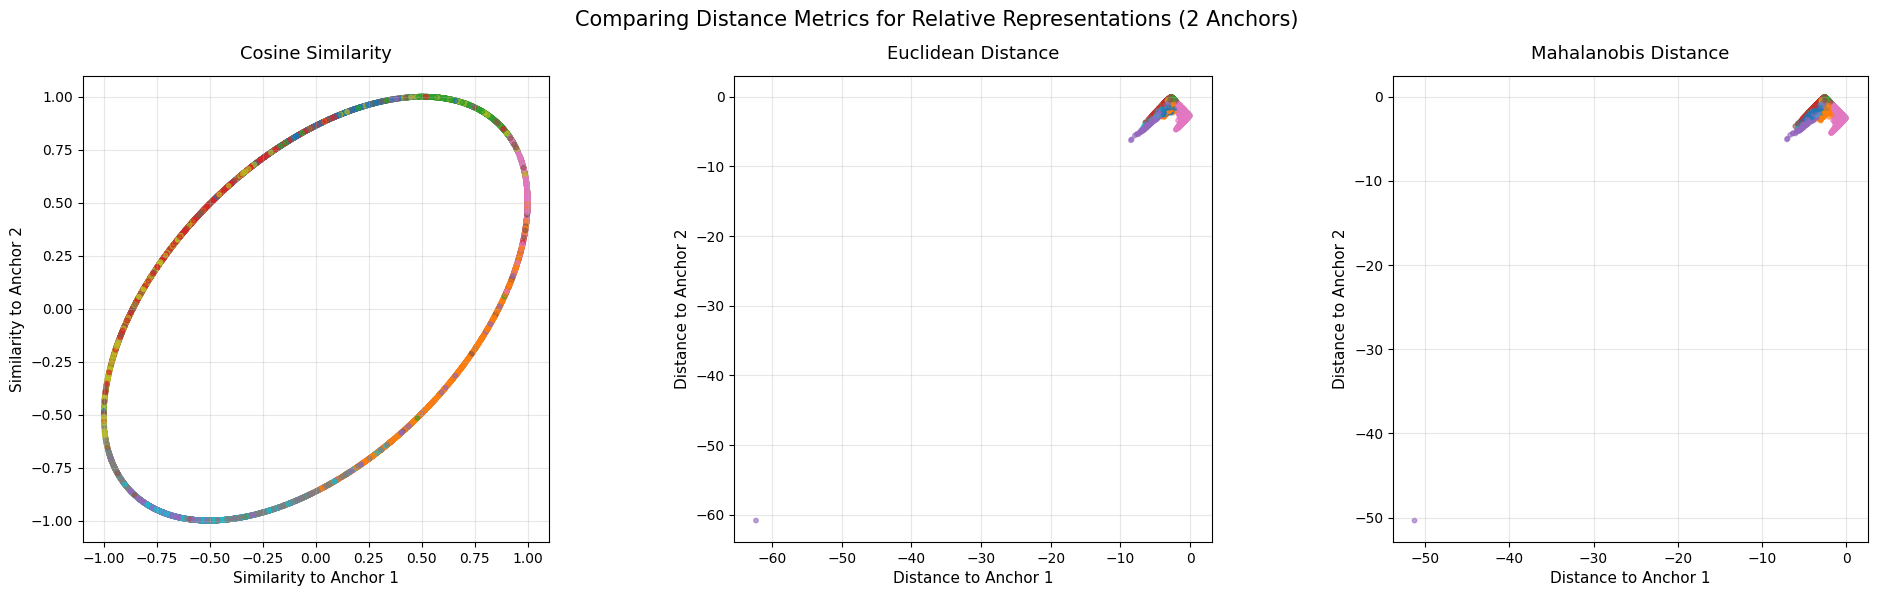

In [44]:
# Plot all three relative representations side by side
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Cosine similarity
axes[0].scatter(relrep_cosine[:, 0], relrep_cosine[:, 1], 
                c=labels_2d, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('Similarity to Anchor 1', fontsize=11)
axes[0].set_ylabel('Similarity to Anchor 2', fontsize=11)
axes[0].set_title('Cosine Similarity', fontsize=13, pad=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Plot 2: Euclidean distance
scatter2 = axes[1].scatter(relrep_euclidean[:, 0], relrep_euclidean[:, 1], 
                           c=labels_2d, cmap='tab10', s=10, alpha=0.6)
axes[1].set_xlabel('Distance to Anchor 1', fontsize=11)
axes[1].set_ylabel('Distance to Anchor 2', fontsize=11)
axes[1].set_title('Euclidean Distance', fontsize=13, pad=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Plot 3: Mahalanobis distance
axes[2].scatter(relrep_mahalanobis[:, 0], relrep_mahalanobis[:, 1], 
                c=labels_2d, cmap='tab10', s=10, alpha=0.6)
axes[2].set_xlabel('Distance to Anchor 1', fontsize=11)
axes[2].set_ylabel('Distance to Anchor 2', fontsize=11)
axes[2].set_title('Mahalanobis Distance', fontsize=13, pad=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.suptitle('Comparing Distance Metrics for Relative Representations (2 Anchors)', 
             fontsize=15, y=0.98)
plt.tight_layout()
plt.show()
